**Experiment 4**

In [1]:
# Cell 1 — Install dependencies
!pip -q install opacus==1.4.0 tqdm pandas matplotlib torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.8/224.8 kB 9.5 MB/s eta 0:00:00


In [2]:
# Cell 2 — Imports + reproducibility
import os, math, random
from copy import deepcopy
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as T

import matplotlib.pyplot as plt

RDP_ALPHAS = (
    [1.01, 1.05] +
    [1.1 + 0.1*i for i in range(0, 90)] +
    list(range(11, 64)) + [64, 128, 256, 512]
)

def seed_all(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cuda


In [3]:
# Cell 3 — Dataset: CIFAR-10 + loaders
# clients use augmentation
# public anchors + test use deterministic transform

transform_train = T.Compose([
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize((0.4914, 0.4822, 0.4465),
                (0.2470, 0.2435, 0.2616))
])

transform_plain = T.Compose([
    T.ToTensor(),
    T.Normalize((0.4914, 0.4822, 0.4465),
                (0.2470, 0.2435, 0.2616))
])

train_ds = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=True, transform=transform_train
)

public_ds = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=False, transform=transform_plain
)

test_ds = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=transform_plain
)

test_loader = DataLoader(
    test_ds, batch_size=512, shuffle=False, num_workers=2, pin_memory=True
)

print("train_ds (clients):", len(train_ds))
print("public_ds (anchors):", len(public_ds))
print("test_ds:", len(test_ds))

100%|██████████| 170M/170M [00:05<00:00, 32.4MB/s]


train_ds (clients): 50000
public_ds (anchors): 50000
test_ds: 10000


In [4]:
# Cell 4 — Public set + IID clients
NUM_CLASSES = 10
PUBLIC_PER_CLASS = 20
SAMPLES_PER_CLIENT = 10
CLIENTS_PER_ROUND = 100

def extract_public_per_class(dataset, per_class=20, seed=0):
    rng = np.random.default_rng(seed)
    targets = np.array(dataset.targets)
    public_idx = []
    for k in range(NUM_CLASSES):
        cls_idx = np.where(targets == k)[0]
        rng.shuffle(cls_idx)
        public_idx.extend(cls_idx[:per_class].tolist())
    return sorted(public_idx)

public_idx = extract_public_per_class(train_ds, per_class=PUBLIC_PER_CLASS, seed=0)

all_train_idx = np.arange(len(train_ds))
mask = np.ones(len(train_ds), dtype=bool)
mask[np.array(public_idx)] = False
avail_idx = all_train_idx[mask]

NUM_CLIENTS = len(avail_idx) // SAMPLES_PER_CLIENT
private_needed = NUM_CLIENTS * SAMPLES_PER_CLIENT
avail_idx = avail_idx[:private_needed]

def build_iid_clients_from_indices(indices, num_clients, samples_per_client, seed=0):
    rng = np.random.default_rng(seed)
    perm = rng.permutation(indices)
    return [perm[i*samples_per_client:(i+1)*samples_per_client].tolist()
            for i in range(num_clients)]

clients = build_iid_clients_from_indices(avail_idx, NUM_CLIENTS, SAMPLES_PER_CLIENT, seed=0)

print("public samples:", len(public_idx), f"(per_class={PUBLIC_PER_CLASS})")
print("private samples:", len(avail_idx))
print("NUM_CLIENTS:", NUM_CLIENTS)
print("samples/client:", SAMPLES_PER_CLIENT)
print("clients/round:", CLIENTS_PER_ROUND)
print("q =", CLIENTS_PER_ROUND / NUM_CLIENTS)

public samples: 200 (per_class=20)
private samples: 49800
NUM_CLIENTS: 4980
samples/client: 10
clients/round: 100
q = 0.020080321285140562


In [5]:
# Cell 5 — Model + evaluation
# GroupNorm model: more stable with tiny client batches

class FMNIST_CNN(nn.Module):
    def __init__(self):
        super().__init__()

        def CBR(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
                nn.GroupNorm(num_groups=8, num_channels=out_ch),
                nn.ReLU(inplace=True),
            )

        self.block1 = nn.Sequential(
            CBR(3, 64),
            CBR(64, 64),
            nn.MaxPool2d(2),  # 32 -> 16
        )
        self.block2 = nn.Sequential(
            CBR(64, 128),
            CBR(128, 128),
            nn.MaxPool2d(2),  # 16 -> 8
        )
        self.block3 = nn.Sequential(
            CBR(128, 256),
            CBR(256, 256),
            nn.MaxPool2d(2),  # 8 -> 4
        )

        self.fc1 = nn.Linear(256 * 4 * 4, 256)
        self.drop = nn.Dropout(p=0.2)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.drop(x)
        return self.fc2(x)

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        pred = model(x).argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.numel()
    return correct / total

In [6]:
# Cell 6 — Tensor-list + flatten helpers
def model_param_list(model):
    return [p for p in model.parameters() if p.requires_grad]

@torch.no_grad()
def zero_like_params(model):
    return [torch.zeros_like(p.data) for p in model_param_list(model)]

@torch.no_grad()
def add_update_(model, update_list, scale=1.0):
    for p, u in zip(model_param_list(model), update_list):
        p.data.add_(u, alpha=scale)

@torch.no_grad()
def add_scaled_list_(dst, src, alpha):
    for d, s in zip(dst, src):
        d.add_(s, alpha=float(alpha))

@torch.no_grad()
def norm_sq_list(tlist):
    s = None
    for t in tlist:
        v = (t * t).sum()
        s = v if s is None else s + v
    return s + 1e-12

@torch.no_grad()
def l2_norm_list(tlist):
    return torch.sqrt(norm_sq_list(tlist))

def sub_list(a, b):
    return [x - y for x, y in zip(a, b)]

@torch.no_grad()
def dot_list(a_list, b_list):
    s = None
    for a, b in zip(a_list, b_list):
        v = (a * b).sum()
        s = v if s is None else s + v
    return s

@torch.no_grad()
def flatten_list(tlist):
    return torch.cat([t.reshape(-1) for t in tlist])

@torch.no_grad()
def unflatten_like(vec, template_list):
    out = []
    idx = 0
    for t in template_list:
        n = t.numel()
        out.append(vec[idx:idx+n].view_as(t))
        idx += n
    return out

In [7]:
# Cell 7 — Local client update (SGD) returns delta = local - global

loss_fn = nn.CrossEntropyLoss()

def client_update(global_model, client_indices, lr, momentum,
                  local_epochs=1, batch_size=10,
                  poison=None,
                  weight_decay=5e-4,
                  nesterov=True):
    """
    poison:
      - None: normal training
      - "label_flip": flip labels
    """
    local_model = deepcopy(global_model).to(device)
    local_model.train()

    loader = DataLoader(
        Subset(train_ds, client_indices),
        batch_size=min(int(batch_size), len(client_indices)),
        shuffle=True,
        drop_last=False
    )

    opt = torch.optim.SGD(
        local_model.parameters(),
        lr=float(lr),
        momentum=float(momentum),
        weight_decay=float(weight_decay),
        nesterov=bool(nesterov) if float(momentum) > 0 else False
    )

    for _ in range(int(local_epochs)):
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            if poison == "label_flip":
                y = (y + 1) % NUM_CLASSES

            opt.zero_grad(set_to_none=True)
            loss = loss_fn(local_model(x), y)
            loss.backward()
            opt.step()

    delta = []
    for lp, gp in zip(model_param_list(local_model), model_param_list(global_model)):
        delta.append((lp.data - gp.data).detach())
    return delta

In [8]:
# Cell 8 — DP accounting (RDP) + sigma search

from opacus.accountants.analysis import rdp as rdp_analysis

def _compute_rdp(q, noise_multiplier, steps, orders):
    try:
        return rdp_analysis.compute_rdp(q=q, noise_multiplier=noise_multiplier, steps=steps, orders=orders)
    except TypeError:
        return rdp_analysis.compute_rdp(q, noise_multiplier, steps, orders)

def _get_eps(orders, rdp, delta):
    try:
        eps, _ = rdp_analysis.get_privacy_spent(orders=orders, rdp=rdp, delta=delta)
    except TypeError:
        eps, _ = rdp_analysis.get_privacy_spent(orders, rdp, delta)
    return float(eps)

def epsilon_from_sigma_single(sigma, q, steps, delta):
    rdp = _compute_rdp(q, float(sigma), int(steps), RDP_ALPHAS)
    return _get_eps(RDP_ALPHAS, rdp, delta)

def epsilon_from_sigma_two(sig_sel, sig_rel, q, steps, delta):
    rdp1 = _compute_rdp(q, float(sig_sel), int(steps), RDP_ALPHAS)
    rdp2 = _compute_rdp(q, float(sig_rel), int(steps), RDP_ALPHAS)
    return _get_eps(RDP_ALPHAS, rdp1 + rdp2, delta)

def find_sigma_for_target_eps_single(target_eps, q, steps, delta, iters=50):
    lo, hi = 1e-4, 1.0
    while epsilon_from_sigma_single(hi, q, steps, delta) > target_eps:
        hi *= 2.0
        if hi > 1e4:
            raise RuntimeError("Could not find sigma upper bound.")
    for _ in range(iters):
        mid = 0.5 * (lo + hi)
        if epsilon_from_sigma_single(mid, q, steps, delta) > target_eps:
            lo = mid
        else:
            hi = mid
    return float(hi)

def find_sigma_rel_for_target_eps_two(target_eps, q, steps, delta, sel_factor=2.0, iters=50):
    lo, hi = 1e-4, 1.0

    def E(sig_rel):
        return epsilon_from_sigma_two(sel_factor * sig_rel, sig_rel, q, steps, delta)

    while E(hi) > target_eps:
        hi *= 2.0
        if hi > 1e4:
            raise RuntimeError("Could not find sigma upper bound (two-noise case).")
    for _ in range(iters):
        mid = 0.5 * (lo + hi)
        if E(mid) > target_eps:
            lo = mid
        else:
            hi = mid
    return float(hi)

In [9]:
# Cell 9 — Attack helpers: ALIE / SF / MINMAX / MINSUM

@torch.no_grad()
def _pairwise_dist_sq(X):
    xx = (X * X).sum(dim=1, keepdim=True)
    dist = xx + xx.t() - 2.0 * (X @ X.t())
    dist.clamp_(min=0.0)
    return dist

@torch.no_grad()
def alie_attack_from_honest_constz(honest_updates, byz_count, z=2.0, direction=-1.0):
    if byz_count <= 0:
        return []
    if len(honest_updates) == 0:
        raise ValueError("No honest updates to build ALIE.")

    P = len(honest_updates[0])
    mal = []
    for j in range(P):
        stacked = torch.stack([u[j] for u in honest_updates], dim=0)
        mu = stacked.mean(dim=0)
        sd = stacked.std(dim=0, unbiased=False) + 1e-12
        mal.append(mu + float(direction) * float(z) * sd)

    mal = [t.detach() for t in mal]
    return [[t.clone() for t in mal] for _ in range(byz_count)]

@torch.no_grad()
def minmax_attack_vec(honest_vecs, byz_count, iters=30):
    if byz_count <= 0:
        return []
    if len(honest_vecs) == 0:
        raise ValueError("No honest vectors to build Min-Max.")

    X = torch.stack(honest_vecs, dim=0)
    mu = X.mean(dim=0)
    sd = X.std(dim=0, unbiased=False) + 1e-12
    p = -sd

    honest_max = float(_pairwise_dist_sq(X).max().item())

    def ok(gamma):
        gm = mu + float(gamma) * p
        dist = ((X - gm) ** 2).sum(dim=1)
        return float(dist.max().item()) <= honest_max

    lo, hi = 0.0, 1.0
    while ok(hi):
        hi *= 2.0
        if hi > 1e4:
            break

    for _ in range(iters):
        mid = 0.5 * (lo + hi)
        if ok(mid):
            lo = mid
        else:
            hi = mid

    gm = (mu + float(lo) * p).detach()
    return [gm.clone() for _ in range(byz_count)]

@torch.no_grad()
def minsum_attack_vec(honest_vecs, byz_count, iters=30):
    if byz_count <= 0:
        return []
    if len(honest_vecs) == 0:
        raise ValueError("No honest vectors to build Min-Sum.")

    X = torch.stack(honest_vecs, dim=0)
    mu = X.mean(dim=0)
    sd = X.std(dim=0, unbiased=False) + 1e-12
    p = -sd

    D = _pairwise_dist_sq(X)
    honest_max_sum = float(D.sum(dim=1).max().item())

    def ok(gamma):
        gm = mu + float(gamma) * p
        dist = ((X - gm) ** 2).sum(dim=1)
        return float(dist.sum().item()) <= honest_max_sum

    lo, hi = 0.0, 1.0
    while ok(hi):
        hi *= 2.0
        if hi > 1e4:
            break

    for _ in range(iters):
        mid = 0.5 * (lo + hi)
        if ok(mid):
            lo = mid
        else:
            hi = mid

    gm = (mu + float(lo) * p).detach()
    return [gm.clone() for _ in range(byz_count)]

@torch.no_grad()
def minmax_attack_from_honest_list(honest_updates, byz_count):
    if byz_count <= 0:
        return []
    template = honest_updates[0]
    honest_vecs = [flatten_list(u).detach() for u in honest_updates]
    mal_vecs = minmax_attack_vec(honest_vecs, byz_count)
    return [unflatten_like(v, template) for v in mal_vecs]

@torch.no_grad()
def minsum_attack_from_honest_list(honest_updates, byz_count):
    if byz_count <= 0:
        return []
    template = honest_updates[0]
    honest_vecs = [flatten_list(u).detach() for u in honest_updates]
    mal_vecs = minsum_attack_vec(honest_vecs, byz_count)
    return [unflatten_like(v, template) for v in mal_vecs]

In [10]:
# Cell 10 — DP-FedAvg robust trainer
# Supports attacks: ALIE / SF / MINMAX / MINSUM

def train_dp_fedavg_robust(seed, eps_total, byz_frac,
                           sigma, delta=1e-5,
                           num_clients=None, clients_per_round=CLIENTS_PER_ROUND,
                           rounds=30, local_epochs=10, batch_size=10,
                           lr0=0.125, lr_decay=0.99, momentum=0.5,
                           clip_C=1.0,
                           attack="ALIE",
                           sf_scale=-1.0,
                           alie_direction=-1.0, alie_z=2.0,
                           return_curve=False, record_every=1):

    seed_all(seed)
    rng = np.random.RandomState(seed)

    if num_clients is None:
        num_clients = len(clients)

    model = FMNIST_CNN().to(device)
    attack = str(attack).upper()

    round_axis, acc_curve = [], []
    if return_curve:
        round_axis.append(0)
        acc_curve.append(evaluate(model, test_loader))

    for t in tqdm(range(rounds), desc=f"DP-FedAvg atk={attack} f={int(100*byz_frac)}%"):
        lr_t = lr0 * (lr_decay ** t)
        chosen = rng.choice(num_clients, size=clients_per_round, replace=False)

        b = int(round(byz_frac * clients_per_round))
        byz_pos = set(rng.choice(clients_per_round, size=b, replace=False)) if b > 0 else set()

        honest_updates = []
        byz_cids = []

        for j, cid in enumerate(chosen):
            if j in byz_pos:
                byz_cids.append(cid)
                continue
            honest_updates.append(
                client_update(model, clients[cid], lr=lr_t, momentum=momentum,
                              local_epochs=local_epochs, batch_size=batch_size)
            )

        if b > 0:
            if attack == "ALIE":
                byz_updates = alie_attack_from_honest_constz(
                    honest_updates, b, z=alie_z, direction=alie_direction
                )
            elif attack == "SF":
                byz_updates = []
                for cid in byz_cids:
                    dlt = client_update(model, clients[cid], lr=lr_t, momentum=momentum,
                                        local_epochs=local_epochs, batch_size=batch_size)
                    byz_updates.append([float(sf_scale) * u for u in dlt])
            elif attack == "MINMAX":
                byz_updates = minmax_attack_from_honest_list(honest_updates, b)
            elif attack == "MINSUM":
                byz_updates = minsum_attack_from_honest_list(honest_updates, b)
            else:
                raise ValueError(f"Unknown attack={attack}")
        else:
            byz_updates = []

        sum_update = zero_like_params(model)

        for upd in honest_updates + byz_updates:
            nrm = l2_norm_list(upd).item()
            scale = min(1.0, clip_C / (nrm + 1e-12))
            add_scaled_list_(sum_update, upd, scale)

        for j in range(len(sum_update)):
            sum_update[j].add_(torch.randn_like(sum_update[j]) * (sigma * clip_C))

        avg_update = [u / clients_per_round for u in sum_update]
        add_update_(model, avg_update, scale=1.0)

        if return_curve and ((t + 1) % record_every == 0):
            round_axis.append(t + 1)
            acc_curve.append(evaluate(model, test_loader))

    if return_curve:
        return round_axis, acc_curve
    return evaluate(model, test_loader)

In [11]:
# Cell 11 — AG-PTR
# Restores the stronger AG-PTR path:
# - public anchors from public_ds (no augmentation)
# - exact squared-distance assignment
# - allow_zero=True
# - lower tau
# - rho=1.0 / pub_scale=0.002 defaults

def public_anchor_update_on_subset(global_model, subset_indices, lr, momentum,
                                   public_epochs=1, pub_batch_size=64,
                                   weight_decay=5e-4, nesterov=True):
    local_model = deepcopy(global_model).to(device)
    local_model.train()

    loader = DataLoader(
        Subset(public_ds, subset_indices),
        batch_size=min(int(pub_batch_size), len(subset_indices)),
        shuffle=True,
        drop_last=False
    )

    opt = torch.optim.SGD(
        local_model.parameters(),
        lr=float(lr),
        momentum=float(momentum),
        weight_decay=float(weight_decay),
        nesterov=bool(nesterov) if float(momentum) > 0 else False
    )

    for _ in range(int(public_epochs)):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad(set_to_none=True)
            loss = loss_fn(local_model(x), y)
            loss.backward()
            opt.step()

    delta_pub = []
    for lp, gp in zip(model_param_list(local_model), model_param_list(global_model)):
        delta_pub.append((lp.data - gp.data).detach())
    return delta_pub


def build_public_anchors(global_model, public_indices, R, lr, momentum,
                         public_epochs=1, pub_batch=20, pub_scale=0.002, seed=0):
    rng = np.random.RandomState(seed)
    anchors = []
    for _ in range(int(R)):
        k = min(int(pub_batch), len(public_indices))
        subset = rng.choice(public_indices, size=k, replace=False).tolist()

        delta_pub = public_anchor_update_on_subset(
            global_model, subset,
            lr=lr, momentum=momentum,
            public_epochs=public_epochs, pub_batch_size=k
        )
        anchors.append([float(pub_scale) * d for d in delta_pub])
    return anchors


def _avg_anchor(anchor_list):
    P = len(anchor_list[0])
    out = []
    for j in range(P):
        out.append(torch.stack([a[j] for a in anchor_list], dim=0).mean(dim=0).detach())
    return out


@torch.no_grad()
def _norm_sq_noeps(tlist):
    s = 0.0
    for t in tlist:
        s += float((t * t).sum().item())
    return s

@torch.no_grad()
def _dist_sq_noeps(a_list, b_list):
    s = 0.0
    for a, b in zip(a_list, b_list):
        d = a - b
        s += float((d * d).sum().item())
    return s


def train_ag_ptr(seed, eps_total, byz_frac,
                 sigma_sel, sigma_rel, delta=1e-5,
                 rounds=30, local_epochs=3, batch_size=10,
                 lr0=0.07, lr_decay=0.99, momentum=0.9,
                 rho=1.0, tau=30,
                 R_pub_avg=8, pub_batch=20, pub_scale=0.002, public_epochs=1,
                 attack="ALIE",
                 sf_scale=-1.0,
                 alie_direction=-1.0, alie_z=2.0,
                 allow_zero=True,
                 return_curve=False, record_every=1):

    seed_all(seed)
    rng = np.random.RandomState(seed)

    num_clients = len(clients)
    clients_per_round = CLIENTS_PER_ROUND

    model = FMNIST_CNN().to(device)
    zero_anchor = zero_like_params(model)

    attack = str(attack).upper()
    accept = 0

    round_axis, acc_curve = [], []
    if return_curve:
        round_axis.append(0)
        acc_curve.append(evaluate(model, test_loader))

    for t in tqdm(range(rounds), desc=f"AG-PTR atk={attack} f={int(100*byz_frac)}%"):
        lr_t = lr0 * (lr_decay ** t)
        chosen = rng.choice(num_clients, size=clients_per_round, replace=False)

        b = int(round(byz_frac * clients_per_round))
        byz_pos = set(rng.choice(clients_per_round, size=b, replace=False)) if b > 0 else set()

        anchors_pub = build_public_anchors(
            model, public_idx,
            R=R_pub_avg, lr=lr_t, momentum=momentum,
            public_epochs=public_epochs, pub_batch=pub_batch, pub_scale=pub_scale,
            seed=seed * 100000 + t
        )
        a_pub = _avg_anchor(anchors_pub)

        honest_updates, honest_slots = [], []
        byz_slots, byz_cids = [], []

        for j, cid in enumerate(chosen):
            if j in byz_pos:
                byz_slots.append(j)
                byz_cids.append(cid)
                continue

            honest_updates.append(
                client_update(model, clients[cid], lr=lr_t, momentum=momentum,
                              local_epochs=local_epochs, batch_size=batch_size)
            )
            honest_slots.append(j)

        if b > 0:
            if attack == "ALIE":
                byz_updates = alie_attack_from_honest_constz(
                    honest_updates, b, z=alie_z, direction=alie_direction
                )
            elif attack == "SF":
                byz_updates = []
                for cid in byz_cids:
                    dlt = client_update(model, clients[cid], lr=lr_t, momentum=momentum,
                                        local_epochs=local_epochs, batch_size=batch_size)
                    byz_updates.append([float(sf_scale) * u for u in dlt])
            elif attack == "MINMAX":
                byz_updates = minmax_attack_from_honest_list(honest_updates, b)
            elif attack == "MINSUM":
                byz_updates = minsum_attack_from_honest_list(honest_updates, b)
            else:
                raise ValueError(f"Unknown attack={attack}")
        else:
            byz_updates = []

        deltas = [None] * clients_per_round
        for upd, j in zip(honest_updates, honest_slots):
            deltas[j] = upd
        for upd, j in zip(byz_updates, byz_slots):
            deltas[j] = upd

        n_pub = 0
        assign = []   # 0=pub, 1=zero
        for dlt in deltas:
            d0 = _norm_sq_noeps(dlt)
            dp = _dist_sq_noeps(dlt, a_pub)
            if dp <= d0:
                assign.append(0)
                n_pub += 1
            else:
                assign.append(1)

        n_zero = clients_per_round - n_pub

        noisy_pub  = float(n_pub)  + rng.normal(0.0, float(sigma_sel))
        noisy_zero = float(n_zero) + rng.normal(0.0, float(sigma_sel))

        if noisy_pub >= noisy_zero:
            r_star, noisy_winner = 0, noisy_pub
        else:
            r_star, noisy_winner = 1, noisy_zero

        if (r_star == 1) and (not allow_zero):
            if return_curve and ((t + 1) % record_every == 0):
                round_axis.append(t + 1)
                acc_curve.append(evaluate(model, test_loader))
            continue

        if float(noisy_winner) < float(tau):
            if return_curve and ((t + 1) % record_every == 0):
                round_axis.append(t + 1)
                acc_curve.append(evaluate(model, test_loader))
            continue

        accept += 1
        a_star = a_pub if r_star == 0 else zero_anchor

        sum_offsets = zero_like_params(model)
        for dlt, r_i in zip(deltas, assign):
            if r_i != r_star:
                continue
            offset = sub_list(dlt, a_star)
            off_norm = float(l2_norm_list(offset).item())
            scale = min(1.0, float(rho) / (off_norm + 1e-12))
            add_scaled_list_(sum_offsets, offset, scale)

        noisy_winner_capped = min(float(clients_per_round), max(0.0, float(noisy_winner)))
        m_hat = max(float(tau), noisy_winner_capped)

        for j in range(len(sum_offsets)):
            sum_offsets[j].add_(torch.randn_like(sum_offsets[j]) * (float(sigma_rel) * float(rho)))

        mean_update = [a + (so / m_hat) for a, so in zip(a_star, sum_offsets)]
        add_update_(model, mean_update, scale=1.0)

        if return_curve and ((t + 1) % record_every == 0):
            round_axis.append(t + 1)
            acc_curve.append(evaluate(model, test_loader))

    if return_curve:
        return round_axis, acc_curve, accept / rounds

    acc = evaluate(model, test_loader)
    return acc, accept / rounds

In [12]:
# Cell 12 — FedVRDP robust trainer
# Supports attacks: ALIE / SF / MINMAX / MINSUM

@torch.no_grad()
def topk_mask_from_vec(vec, k):
    d = vec.numel()
    k = min(int(k), d)
    mask = torch.zeros(d, device=vec.device)
    if k > 0:
        idx = torch.topk(vec.abs(), k, sorted=False).indices
        mask[idx] = 1.0
    return mask

def train_fedvrdp_robust(seed, eps_total, byz_frac,
                         sigma, delta=1e-5,
                         num_clients=None, clients_per_round=CLIENTS_PER_ROUND,
                         rounds=30, local_epochs=10, batch_size=10,
                         lr0=0.125, lr_decay=0.99, momentum=0.5,
                         clip_C=0.5, k_frac=0.3,
                         attack="ALIE",
                         sf_scale=-1.0,
                         alie_direction=-1.0, alie_z=2.0,
                         return_curve=False, record_every=1):

    seed_all(seed)
    rng = np.random.RandomState(seed)

    if num_clients is None:
        num_clients = len(clients)

    model = FMNIST_CNN().to(device)
    attack = str(attack).upper()

    template = zero_like_params(model)
    d = sum(t.numel() for t in template)
    k = max(1, int(k_frac * d))

    mask = torch.ones(d, device=device)

    round_axis, acc_curve = [], []
    if return_curve:
        round_axis.append(0)
        acc_curve.append(evaluate(model, test_loader))

    for t in tqdm(range(rounds), desc=f"FedVRDP atk={attack} f={int(100*byz_frac)}%"):
        lr_t = lr0 * (lr_decay ** t)
        chosen = rng.choice(num_clients, size=clients_per_round, replace=False)

        b = int(round(byz_frac * clients_per_round))
        byz_pos = set(rng.choice(clients_per_round, size=b, replace=False)) if b > 0 else set()

        honest_vecs, honest_slots = [], []
        byz_slots, byz_cids = [], []

        for j, cid in enumerate(chosen):
            if j in byz_pos:
                byz_slots.append(j)
                byz_cids.append(cid)
                continue

            dlt = client_update(model, clients[cid], lr=lr_t, momentum=momentum,
                                local_epochs=local_epochs, batch_size=batch_size)

            v = flatten_list(dlt).to(device) * mask
            nrm = torch.norm(v) + 1e-12
            v = v * min(1.0, clip_C / float(nrm))

            honest_vecs.append(v)
            honest_slots.append(j)

        if b > 0:
            if attack == "ALIE":
                mats = torch.stack(honest_vecs, dim=0)
                mu = mats.mean(dim=0)
                sd = mats.std(dim=0, unbiased=False) + 1e-12
                mal = mu + float(alie_direction) * float(alie_z) * sd
                mal = mal * mask
                nrm = torch.norm(mal) + 1e-12
                mal = mal * min(1.0, clip_C / float(nrm))
                byz_vecs = [mal.clone().detach() for _ in range(b)]

            elif attack == "SF":
                byz_vecs = []
                for cid in byz_cids:
                    dlt = client_update(model, clients[cid], lr=lr_t, momentum=momentum,
                                        local_epochs=local_epochs, batch_size=batch_size)
                    v = float(sf_scale) * flatten_list(dlt).to(device) * mask
                    nrm = torch.norm(v) + 1e-12
                    v = v * min(1.0, clip_C / float(nrm))
                    byz_vecs.append(v.detach())

            elif attack == "MINMAX":
                mal_vecs = minmax_attack_vec(honest_vecs, b)
                byz_vecs = []
                for v in mal_vecs:
                    v = v.to(device) * mask
                    nrm = torch.norm(v) + 1e-12
                    v = v * min(1.0, clip_C / float(nrm))
                    byz_vecs.append(v.detach())

            elif attack == "MINSUM":
                mal_vecs = minsum_attack_vec(honest_vecs, b)
                byz_vecs = []
                for v in mal_vecs:
                    v = v.to(device) * mask
                    nrm = torch.norm(v) + 1e-12
                    v = v * min(1.0, clip_C / float(nrm))
                    byz_vecs.append(v.detach())
            else:
                raise ValueError(f"Unknown attack={attack}")
        else:
            byz_vecs = []

        updates = [None] * clients_per_round
        for v, j in zip(honest_vecs, honest_slots):
            updates[j] = v
        for v, j in zip(byz_vecs, byz_slots):
            updates[j] = v

        sum_vec = torch.stack(updates, dim=0).sum(dim=0)
        sum_vec = sum_vec + torch.randn_like(sum_vec) * (sigma * clip_C) * mask
        avg_vec = sum_vec / clients_per_round

        avg_list = unflatten_like(avg_vec, template)
        add_update_(model, avg_list, scale=1.0)

        mask = topk_mask_from_vec(avg_vec.detach(), k)

        if return_curve and ((t + 1) % record_every == 0):
            round_axis.append(t + 1)
            acc_curve.append(evaluate(model, test_loader))

    if return_curve:
        return round_axis, acc_curve
    return evaluate(model, test_loader)

In [13]:
# Cell 13 — Robust baselines (non-DP): Median / TrimmedMean / Krum / SparseFed
# Supports attacks: ALIE / SF / MINMAX / MINSUM

@torch.no_grad()
def _make_projection(d, k=2048, seed=0):
    rng = np.random.RandomState(seed)
    k = min(int(k), int(d))
    idx = rng.choice(d, size=k, replace=False)
    sign = rng.choice([-1.0, 1.0], size=k).astype(np.float32)
    idx_t = torch.tensor(idx, device=device, dtype=torch.long)
    sign_t = torch.tensor(sign, device=device, dtype=torch.float32)
    return idx_t, sign_t

@torch.no_grad()
def _krum_index_from_proj(Xp, f):
    m = Xp.shape[0]
    nb = m - f - 2
    if nb <= 0:
        raise ValueError(f"Krum needs m - f - 2 > 0, got m={m}, f={f}")
    dist = _pairwise_dist_sq(Xp)
    dist.fill_diagonal_(float("inf"))
    vals, _ = torch.topk(dist, k=nb, largest=False, sorted=False, dim=1)
    scores = vals.sum(dim=1)
    return int(torch.argmin(scores).item())

@torch.no_grad()
def agg_median_vec(vecs):
    X = torch.stack(vecs, dim=0)
    return X.median(dim=0).values.detach()

@torch.no_grad()
def agg_trimmed_mean_vec(vecs, beta):
    X = torch.stack(vecs, dim=0)
    m = X.shape[0]
    beta = int(beta)
    beta = min(beta, (m - 1)//2)
    Xs, _ = torch.sort(X, dim=0)
    if beta > 0:
        Xs = Xs[beta:m-beta]
    return Xs.mean(dim=0).detach()

@torch.no_grad()
def agg_krum_vec(vecs, f, proj_idx, proj_sign):
    X = torch.stack(vecs, dim=0)
    Xp = X[:, proj_idx] * proj_sign
    j = _krum_index_from_proj(Xp, f)
    return X[j].detach()

def train_robust_baseline(seed, byz_frac,
                          rounds=30, local_epochs=10, batch_size=10,
                          lr0=0.125, lr_decay=0.99, momentum=0.5,
                          agg="MEDIAN",
                          attack="ALIE",
                          sf_scale=-1.0,
                          alie_direction=-1.0, alie_z=2.0,
                          proj_k=2048,
                          return_curve=False, record_every=1):
    seed_all(seed)
    rng = np.random.RandomState(seed)

    num_clients = len(clients)
    m = CLIENTS_PER_ROUND

    model = FMNIST_CNN().to(device)
    template = zero_like_params(model)
    d = sum(t.numel() for t in template)
    proj_idx, proj_sign = _make_projection(d, k=proj_k, seed=seed + 999)

    agg = str(agg).upper()
    attack = str(attack).upper()

    round_axis, acc_curve = [], []
    if return_curve:
        round_axis.append(0)
        acc_curve.append(evaluate(model, test_loader))

    for t in tqdm(range(rounds), desc=f"{agg} (non-DP) atk={attack} f={int(100*byz_frac)}%"):
        lr_t = lr0 * (lr_decay ** t)
        chosen = rng.choice(num_clients, size=m, replace=False)

        b = int(round(byz_frac * m))
        byz_pos = set(rng.choice(m, size=b, replace=False)) if b > 0 else set()

        honest_updates = []
        byz_cids, byz_slots = [], []
        honest_slots = []

        for j, cid in enumerate(chosen):
            if j in byz_pos:
                byz_slots.append(j)
                byz_cids.append(cid)
                continue
            honest_updates.append(
                client_update(model, clients[cid], lr=lr_t, momentum=momentum,
                              local_epochs=local_epochs, batch_size=batch_size)
            )
            honest_slots.append(j)

        if b > 0:
            if attack == "ALIE":
                byz_updates = alie_attack_from_honest_constz(
                    honest_updates, b, z=float(alie_z), direction=float(alie_direction)
                )
            elif attack == "SF":
                byz_updates = []
                for cid in byz_cids:
                    dlt = client_update(model, clients[cid], lr=lr_t, momentum=momentum,
                                        local_epochs=local_epochs, batch_size=batch_size)
                    byz_updates.append([float(sf_scale) * u for u in dlt])
            elif attack == "MINMAX":
                byz_updates = minmax_attack_from_honest_list(honest_updates, b)
            elif attack == "MINSUM":
                byz_updates = minsum_attack_from_honest_list(honest_updates, b)
            else:
                raise ValueError(f"Unknown attack={attack}")
        else:
            byz_updates = []

        deltas = [None] * m
        for upd, j in zip(honest_updates, honest_slots):
            deltas[j] = upd
        for upd, j in zip(byz_updates, byz_slots):
            deltas[j] = upd

        vecs = [flatten_list(u).detach() for u in deltas]

        if agg == "MEDIAN":
            agg_vec = agg_median_vec(vecs)
        elif agg in ("TRIMMEAN", "TRIMMEDMEAN"):
            agg_vec = agg_trimmed_mean_vec(vecs, beta=b)
        elif agg == "KRUM":
            agg_vec = agg_krum_vec(vecs, f=b, proj_idx=proj_idx, proj_sign=proj_sign)
        else:
            raise ValueError(f"Unknown agg={agg}")

        add_update_(model, unflatten_like(agg_vec, template), scale=1.0)

        if return_curve and ((t + 1) % record_every == 0):
            round_axis.append(t + 1)
            acc_curve.append(evaluate(model, test_loader))

    if return_curve:
        return round_axis, acc_curve
    return evaluate(model, test_loader)

def train_sparsefed_baseline(seed, byz_frac,
                             rounds=30, local_epochs=10, batch_size=10,
                             lr0=0.125, lr_decay=0.99, momentum=0.5,
                             clip_C=0.5, k_frac=0.3,
                             attack="ALIE",
                             sf_scale=-1.0,
                             alie_direction=-1.0, alie_z=2.0,
                             return_curve=False, record_every=1):
    """
    SparseFed (non-DP) = non-private top-k sparse aggregation,
    i.e. FedVRDP without the DP noise term.
    """
    seed_all(seed)
    rng = np.random.RandomState(seed)

    num_clients = len(clients)
    m = CLIENTS_PER_ROUND

    model = FMNIST_CNN().to(device)
    template = zero_like_params(model)
    d = sum(t.numel() for t in template)
    k = max(1, int(k_frac * d))

    attack = str(attack).upper()
    mask = torch.ones(d, device=device)

    round_axis, acc_curve = [], []
    if return_curve:
        round_axis.append(0)
        acc_curve.append(evaluate(model, test_loader))

    for t in tqdm(range(rounds), desc=f"SparseFed (non-DP) atk={attack} f={int(100*byz_frac)}%"):
        lr_t = lr0 * (lr_decay ** t)
        chosen = rng.choice(num_clients, size=m, replace=False)

        b = int(round(byz_frac * m))
        byz_pos = set(rng.choice(m, size=b, replace=False)) if b > 0 else set()

        honest_vecs, honest_slots = [], []
        byz_slots, byz_cids = [], []

        for j, cid in enumerate(chosen):
            if j in byz_pos:
                byz_slots.append(j)
                byz_cids.append(cid)
                continue

            dlt = client_update(model, clients[cid], lr=lr_t, momentum=momentum,
                                local_epochs=local_epochs, batch_size=batch_size)
            v = flatten_list(dlt).to(device) * mask
            nrm = torch.norm(v) + 1e-12
            v = v * min(1.0, clip_C / float(nrm))
            honest_vecs.append(v)
            honest_slots.append(j)

        if b > 0:
            if attack == "ALIE":
                mats = torch.stack(honest_vecs, dim=0)
                mu = mats.mean(dim=0)
                sd = mats.std(dim=0, unbiased=False) + 1e-12
                mal = mu + float(alie_direction) * float(alie_z) * sd
                mal = mal * mask
                nrm = torch.norm(mal) + 1e-12
                mal = mal * min(1.0, clip_C / float(nrm))
                byz_vecs = [mal.clone().detach() for _ in range(b)]

            elif attack == "SF":
                byz_vecs = []
                for cid in byz_cids:
                    dlt = client_update(model, clients[cid], lr=lr_t, momentum=momentum,
                                        local_epochs=local_epochs, batch_size=batch_size)
                    v = float(sf_scale) * flatten_list(dlt).to(device) * mask
                    nrm = torch.norm(v) + 1e-12
                    v = v * min(1.0, clip_C / float(nrm))
                    byz_vecs.append(v.detach())

            elif attack == "MINMAX":
                mal_vecs = minmax_attack_vec(honest_vecs, b)
                byz_vecs = []
                for v in mal_vecs:
                    v = v.to(device) * mask
                    nrm = torch.norm(v) + 1e-12
                    v = v * min(1.0, clip_C / float(nrm))
                    byz_vecs.append(v.detach())

            elif attack == "MINSUM":
                mal_vecs = minsum_attack_vec(honest_vecs, b)
                byz_vecs = []
                for v in mal_vecs:
                    v = v.to(device) * mask
                    nrm = torch.norm(v) + 1e-12
                    v = v * min(1.0, clip_C / float(nrm))
                    byz_vecs.append(v.detach())
            else:
                raise ValueError(f"Unknown attack={attack}")
        else:
            byz_vecs = []

        updates = [None] * m
        for v, j in zip(honest_vecs, honest_slots):
            updates[j] = v
        for v, j in zip(byz_vecs, byz_slots):
            updates[j] = v

        sum_vec = torch.stack(updates, dim=0).sum(dim=0)
        avg_vec = sum_vec / m

        avg_list = unflatten_like(avg_vec, template)
        add_update_(model, avg_list, scale=1.0)

        mask = topk_mask_from_vec(avg_vec.detach(), k)

        if return_curve and ((t + 1) % record_every == 0):
            round_axis.append(t + 1)
            acc_curve.append(evaluate(model, test_loader))

    if return_curve:
        return round_axis, acc_curve
    return evaluate(model, test_loader)

Smoke benchmark: eps=4.0, f=0.3, rounds=20
sigma_dp: 0.6629829470363837
sigma_sel/sigma_rel: 1.327783707822995 0.6638918539114975

Smoke attack: ALIE


SparseFed (non-DP) atk=ALIE f=30%: 100%|██████████| 20/20 [00:18<00:00,  1.06it/s]


Smoke attack: SF



SparseFed (non-DP) atk=SF f=30%: 100%|██████████| 20/20 [00:24<00:00,  1.22s/it]


Smoke attack: MINMAX



SparseFed (non-DP) atk=MINMAX f=30%: 100%|██████████| 20/20 [00:20<00:00,  1.03s/it]


Smoke attack: MINSUM



SparseFed (non-DP) atk=MINSUM f=30%: 100%|██████████| 20/20 [00:20<00:00,  1.04s/it]


,attack,f,DP-FedAvg,FedVRDP,AG-PTR,AG-PTR_accept_rate,Median (non-DP),TrimmedMean (non-DP),Krum (non-DP),SparseFed (non-DP)
0,ALIE,0.3,0.1037,0.1001,0.0993,1.0,0.1000,0.1000,0.1000,0.1272
1,SF,0.3,0.1166,0.1514,0.1223,0.6,0.1727,0.1847,0.1000,0.1714
2,MINMAX,0.3,0.1042,0.1001,0.0998,1.0,0.1000,0.1000,0.1001,0.1000
3,MINSUM,0.3,0.0993,0.1001,0.0993,1.0,0.1000,0.1000,0.1001,0.1000


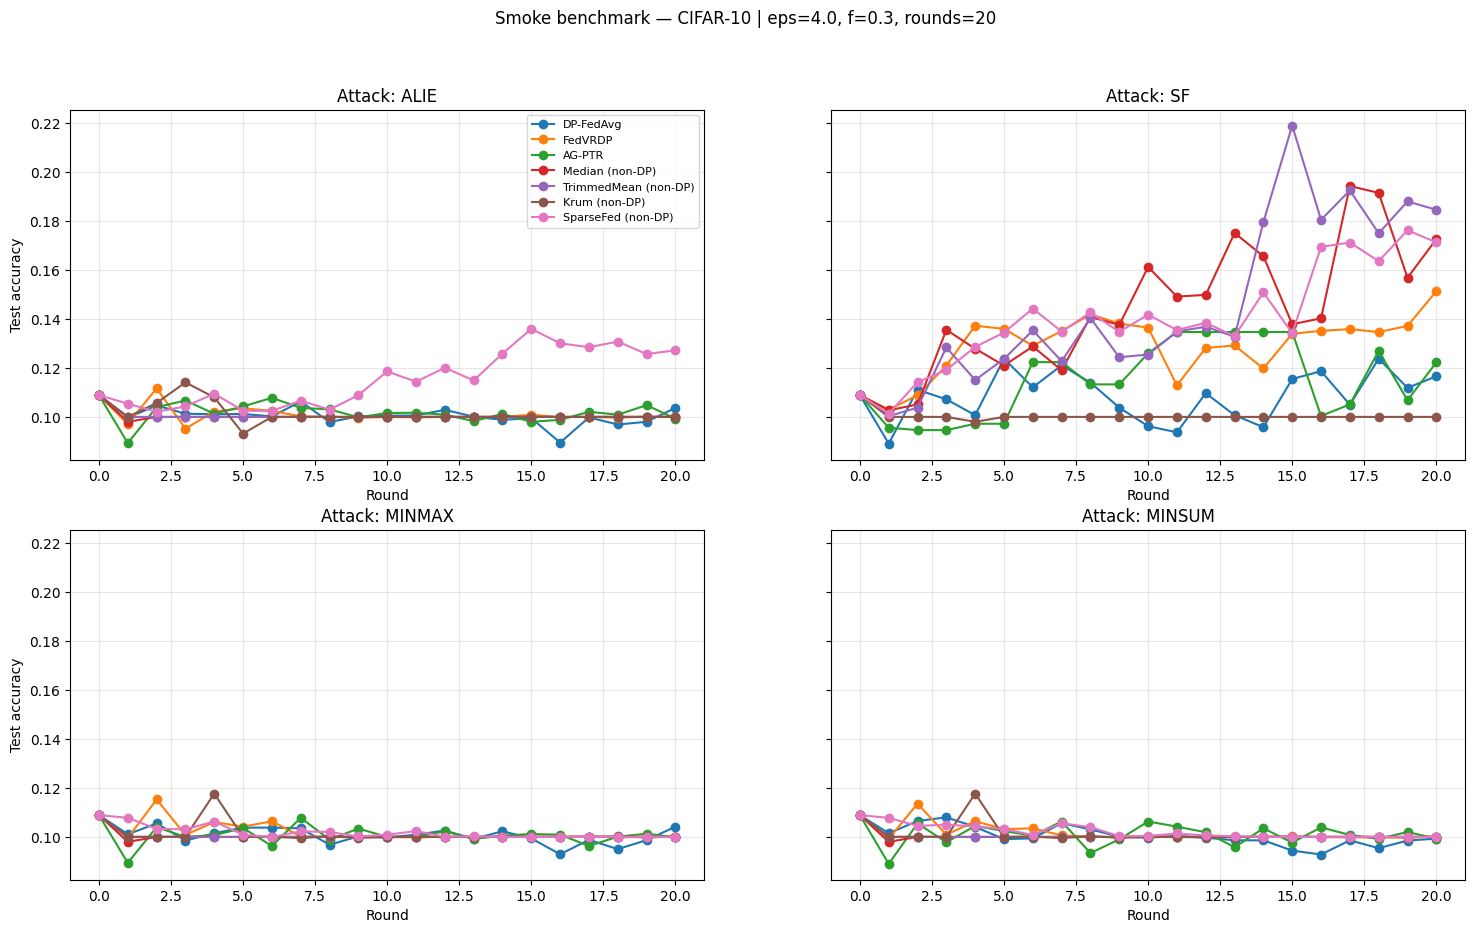

In [15]:
# Cell 14 — Smoke benchmark
# Methods: DP-FedAvg / FedVRDP / AG-PTR / Median / TrimmedMean / Krum / SparseFed
# Attacks: ALIE / SF / MINMAX / MINSUM
# This keeps f=0.20 because your better results were in that regime.

seed = 0
EPS_TOTAL = 4.0
DELTA = 1e-5
F_FIXED = 0.30

ROUNDS = 20
LOCAL_EPOCHS = 3
BATCH_SIZE = 10

LR0 = 0.07
LR_DECAY = 0.99
MOMENTUM = 0.9

ATTACKS = ["ALIE", "SF", "MINMAX", "MINSUM"]

ALIE_Z = 2.0
ALIE_DIR = -1.0
SF_SCALE = -1.0

# AG-PTR params: restored stronger version
RHO = 0.79
TAU = 55
R_PUB_AVG = 8
PUB_BATCH = 20
PUB_SCALE = 0.1
PUBLIC_EPOCHS = 1
ALLOW_ZERO = True
SEL_FACTOR = 2.0

# DP baselines
CLIP_C_DP = 1.0
CLIP_C_VR = 0.5
K_FRAC = 0.30

ROBUST_AGGS = {
    "Median (non-DP)": "MEDIAN",
    "TrimmedMean (non-DP)": "TRIMMEAN",
    "Krum (non-DP)": "KRUM",
}

q = CLIENTS_PER_ROUND / len(clients)
sigma_dp = find_sigma_for_target_eps_single(EPS_TOTAL, q, ROUNDS, DELTA)
sigma_rel = find_sigma_rel_for_target_eps_two(EPS_TOTAL, q, ROUNDS, DELTA, sel_factor=SEL_FACTOR)
sigma_sel = SEL_FACTOR * sigma_rel

print(f"Smoke benchmark: eps={EPS_TOTAL}, f={F_FIXED}, rounds={ROUNDS}")
print("sigma_dp:", sigma_dp)
print("sigma_sel/sigma_rel:", sigma_sel, sigma_rel)

METHODS = [
    "DP-FedAvg", "FedVRDP", "AG-PTR",
    "Median (non-DP)", "TrimmedMean (non-DP)", "Krum (non-DP)", "SparseFed (non-DP)"
]

curves = {atk: {} for atk in ATTACKS}
rows = []

for atk in ATTACKS:
    print("\n==============================")
    print("Smoke attack:", atk)
    print("==============================")

    r_dp, c_dp = train_dp_fedavg_robust(
        seed, EPS_TOTAL, F_FIXED, sigma_dp, delta=DELTA,
        rounds=ROUNDS, local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE,
        lr0=LR0, lr_decay=LR_DECAY, momentum=MOMENTUM,
        clip_C=CLIP_C_DP,
        attack=atk, sf_scale=SF_SCALE, alie_direction=ALIE_DIR, alie_z=ALIE_Z,
        return_curve=True, record_every=1
    )

    r_vr, c_vr = train_fedvrdp_robust(
        seed, EPS_TOTAL, F_FIXED, sigma_dp, delta=DELTA,
        rounds=ROUNDS, local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE,
        lr0=LR0, lr_decay=LR_DECAY, momentum=MOMENTUM,
        clip_C=CLIP_C_VR, k_frac=K_FRAC,
        attack=atk, sf_scale=SF_SCALE, alie_direction=ALIE_DIR, alie_z=ALIE_Z,
        return_curve=True, record_every=1
    )

    r_ag, c_ag, ar_ag = train_ag_ptr(
        seed, EPS_TOTAL, F_FIXED,
        sigma_sel, sigma_rel, delta=DELTA,
        rounds=ROUNDS, local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE,
        lr0=LR0, lr_decay=LR_DECAY, momentum=MOMENTUM,
        rho=RHO, tau=TAU,
        R_pub_avg=R_PUB_AVG, pub_batch=PUB_BATCH, pub_scale=PUB_SCALE, public_epochs=PUBLIC_EPOCHS,
        attack=atk, sf_scale=SF_SCALE, alie_direction=ALIE_DIR, alie_z=ALIE_Z,
        allow_zero=ALLOW_ZERO,
        return_curve=True, record_every=1
    )

    curves[atk]["DP-FedAvg"] = (r_dp, c_dp)
    curves[atk]["FedVRDP"]   = (r_vr, c_vr)
    curves[atk]["AG-PTR"]    = (r_ag, c_ag)

    row = {
        "attack": atk,
        "f": F_FIXED,
        "DP-FedAvg": float(c_dp[-1]),
        "FedVRDP": float(c_vr[-1]),
        "AG-PTR": float(c_ag[-1]),
        "AG-PTR_accept_rate": float(ar_ag),
    }

    for name, agg in ROBUST_AGGS.items():
        r_rb, c_rb = train_robust_baseline(
            seed, F_FIXED,
            agg=agg,
            rounds=ROUNDS, local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE,
            lr0=LR0, lr_decay=LR_DECAY, momentum=MOMENTUM,
            attack=atk, sf_scale=SF_SCALE, alie_direction=ALIE_DIR, alie_z=ALIE_Z,
            return_curve=True, record_every=1
        )
        curves[atk][name] = (r_rb, c_rb)
        row[name] = float(c_rb[-1])

    r_sp, c_sp = train_sparsefed_baseline(
        seed, F_FIXED,
        rounds=ROUNDS, local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE,
        lr0=LR0, lr_decay=LR_DECAY, momentum=MOMENTUM,
        clip_C=CLIP_C_VR, k_frac=K_FRAC,
        attack=atk, sf_scale=SF_SCALE, alie_direction=ALIE_DIR, alie_z=ALIE_Z,
        return_curve=True, record_every=1
    )
    curves[atk]["SparseFed (non-DP)"] = (r_sp, c_sp)
    row["SparseFed (non-DP)"] = float(c_sp[-1])

    rows.append(row)

df_smoke = pd.DataFrame(rows)
display(df_smoke)

fig, axes = plt.subplots(2, 2, figsize=(18, 10), sharey=True)

for i, atk in enumerate(ATTACKS):
    ax = axes[i // 2, i % 2]
    for m in METHODS:
        r, c = curves[atk][m]
        ax.plot(r, c, marker="o", label=m)
    ax.set_title(f"Attack: {atk}")
    ax.set_xlabel("Round")
    ax.grid(True, alpha=0.3)

axes[0, 0].set_ylabel("Test accuracy")
axes[1, 0].set_ylabel("Test accuracy")
axes[0, 0].legend(fontsize=8)

plt.suptitle(f"Smoke benchmark — CIFAR-10 | eps={EPS_TOTAL}, f={F_FIXED}, rounds={ROUNDS}")
plt.show()

Exp4 Smoke: CIFAR-10 | ε_total=4.0 | f=0.2 | attacks=['LF', 'ALIE']
DP sigma (computed for 180 rounds): 0.7861287059898749
AG sigmas sel/rel (computed for 180 rounds): 1.5841110903466515 0.7920555451733258
NOTE: Robust baselines are NON-DP (no DP noise).

Smoke test attack: LF


BULYAN (non-DP) atk=LF f=20%: 100%|██████████| 20/20 [00:09<00:00,  2.02it/s]


Smoke test attack: ALIE



BULYAN (non-DP) atk=ALIE f=20%: 100%|██████████| 20/20 [00:09<00:00,  2.16it/s]


,attack,DP-FedAvg,FedVRDP,AG-PTR,AG-PTR_accept_rate,Median (non-DP),TrimmedMean (non-DP),Krum (non-DP),Bulyan (non-DP)
0,LF,0.1626,0.1417,0.1914,0.95,0.1956,0.2053,0.1639,0.2152
1,ALIE,0.1611,0.1701,0.1056,0.35,0.1000,0.1626,0.1658,0.2168


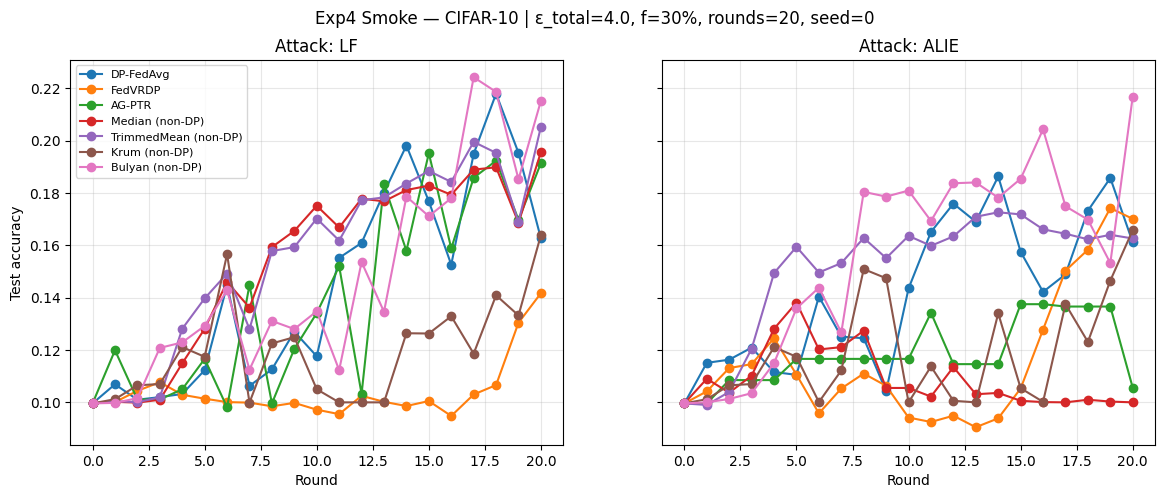

In [ ]:
# Cell 15 — Full benchmark
# Methods: DP-FedAvg / FedVRDP / AG-PTR / Median / TrimmedMean / Krum / SparseFed
# Attacks: ALIE / SF / MINMAX / MINSUM
# Uses the restored AG-PTR path.

seed_list = [0, 1, 2]

EPS_LIST = [4.0, 8.0]
DELTA = 1e-5
F_FIXED = 0.20

ROUNDS = 180
RECORD_EVERY = 5
assert ROUNDS % RECORD_EVERY == 0

LOCAL_EPOCHS = 3
BATCH_SIZE = 10

LR0 = 0.07
LR_DECAY = 0.99
MOMENTUM = 0.9

ATTACKS = ["ALIE", "SF", "MINMAX", "MINSUM"]

ALIE_Z = 2.0
ALIE_DIR = -1.0
SF_SCALE = -1.0

# AG-PTR params: restored stronger version
RHO = 1.0
TAU = 30
R_PUB_AVG = 8
PUB_BATCH = 20
PUB_SCALE = 0.002
PUBLIC_EPOCHS = 1
ALLOW_ZERO = True
SEL_FACTOR = 2.0

# DP baselines
CLIP_C_DP = 1.0
CLIP_C_VR = 0.5
K_FRAC = 0.30

ROBUST_AGGS = {
    "Median (non-DP)": "MEDIAN",
    "TrimmedMean (non-DP)": "TRIMMEAN",
    "Krum (non-DP)": "KRUM",
}

DP_METHODS = ["DP-FedAvg", "FedVRDP", "AG-PTR"]
NONDP_METHODS = ["Median (non-DP)", "TrimmedMean (non-DP)", "Krum (non-DP)", "SparseFed (non-DP)"]
METHODS = DP_METHODS + NONDP_METHODS

round_axis = np.arange(0, ROUNDS + 1, RECORD_EVERY, dtype=int)
q = CLIENTS_PER_ROUND / len(clients)

# Non-DP once
curves_raw_nondp = {atk: {m: [] for m in NONDP_METHODS} for atk in ATTACKS}
print("Computing non-DP baselines once...")
for atk in ATTACKS:
    for seed in seed_list:
        for name, agg in ROBUST_AGGS.items():
            r_rb, c_rb = train_robust_baseline(
                seed, F_FIXED,
                rounds=ROUNDS, local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE,
                lr0=LR0, lr_decay=LR_DECAY, momentum=MOMENTUM,
                agg=agg, attack=atk,
                sf_scale=SF_SCALE, alie_direction=ALIE_DIR, alie_z=ALIE_Z,
                return_curve=True, record_every=RECORD_EVERY
            )
            curves_raw_nondp[atk][name].append(np.array(c_rb, dtype=float))

        r_sp, c_sp = train_sparsefed_baseline(
            seed, F_FIXED,
            rounds=ROUNDS, local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE,
            lr0=LR0, lr_decay=LR_DECAY, momentum=MOMENTUM,
            clip_C=CLIP_C_VR, k_frac=K_FRAC,
            attack=atk, sf_scale=SF_SCALE, alie_direction=ALIE_DIR, alie_z=ALIE_Z,
            return_curve=True, record_every=RECORD_EVERY
        )
        curves_raw_nondp[atk]["SparseFed (non-DP)"].append(np.array(c_sp, dtype=float))

# DP methods per epsilon
curves_raw_dp = {eps: {atk: {m: [] for m in DP_METHODS} for atk in ATTACKS} for eps in EPS_LIST}
agptr_accept_rates = {eps: {atk: [] for atk in ATTACKS} for eps in EPS_LIST}

for eps_total in EPS_LIST:
    sigma_dp = find_sigma_for_target_eps_single(eps_total, q, ROUNDS, DELTA)
    sigma_rel = find_sigma_rel_for_target_eps_two(eps_total, q, ROUNDS, DELTA, sel_factor=SEL_FACTOR)
    sigma_sel = SEL_FACTOR * sigma_rel

    print("\n==============================")
    print(f"FULL run: eps={eps_total}, f={F_FIXED}")
    print("==============================")
    print("sigma_dp:", sigma_dp)
    print("sigma_sel/sigma_rel:", sigma_sel, sigma_rel)

    for atk in ATTACKS:
        for seed in seed_list:
            r_dp, c_dp = train_dp_fedavg_robust(
                seed, eps_total, F_FIXED, sigma_dp, delta=DELTA,
                rounds=ROUNDS, local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE,
                lr0=LR0, lr_decay=LR_DECAY, momentum=MOMENTUM,
                clip_C=CLIP_C_DP,
                attack=atk, sf_scale=SF_SCALE, alie_direction=ALIE_DIR, alie_z=ALIE_Z,
                return_curve=True, record_every=RECORD_EVERY
            )
            curves_raw_dp[eps_total][atk]["DP-FedAvg"].append(np.array(c_dp, dtype=float))

            r_vr, c_vr = train_fedvrdp_robust(
                seed, eps_total, F_FIXED, sigma_dp, delta=DELTA,
                rounds=ROUNDS, local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE,
                lr0=LR0, lr_decay=LR_DECAY, momentum=MOMENTUM,
                clip_C=CLIP_C_VR, k_frac=K_FRAC,
                attack=atk, sf_scale=SF_SCALE, alie_direction=ALIE_DIR, alie_z=ALIE_Z,
                return_curve=True, record_every=RECORD_EVERY
            )
            curves_raw_dp[eps_total][atk]["FedVRDP"].append(np.array(c_vr, dtype=float))

            r_ag, c_ag, ar = train_ag_ptr(
                seed, eps_total, F_FIXED,
                sigma_sel, sigma_rel, delta=DELTA,
                rounds=ROUNDS, local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE,
                lr0=LR0, lr_decay=LR_DECAY, momentum=MOMENTUM,
                rho=RHO, tau=TAU,
                R_pub_avg=R_PUB_AVG, pub_batch=PUB_BATCH, pub_scale=PUB_SCALE, public_epochs=PUBLIC_EPOCHS,
                attack=atk, sf_scale=SF_SCALE, alie_direction=ALIE_DIR, alie_z=ALIE_Z,
                allow_zero=ALLOW_ZERO,
                return_curve=True, record_every=RECORD_EVERY
            )
            curves_raw_dp[eps_total][atk]["AG-PTR"].append(np.array(c_ag, dtype=float))
            agptr_accept_rates[eps_total][atk].append(float(ar))

results = {eps: {atk: {} for atk in ATTACKS} for eps in EPS_LIST}
for eps_total in EPS_LIST:
    for atk in ATTACKS:
        for m in DP_METHODS:
            mat = np.stack(curves_raw_dp[eps_total][atk][m], axis=0)
            results[eps_total][atk][m] = {"mean": mat.mean(axis=0), "std": mat.std(axis=0)}
        for m in NONDP_METHODS:
            mat = np.stack(curves_raw_nondp[atk][m], axis=0)
            results[eps_total][atk][m] = {"mean": mat.mean(axis=0), "std": mat.std(axis=0)}

summary_rows = []
for eps_total in EPS_LIST:
    for atk in ATTACKS:
        row = {"attack": atk, "f": F_FIXED, "eps_total": eps_total}
        for m in METHODS:
            row[f"{m}_mean"] = float(results[eps_total][atk][m]["mean"][-1])
            row[f"{m}_std"]  = float(results[eps_total][atk][m]["std"][-1])

        ar = np.array(agptr_accept_rates[eps_total][atk], dtype=float)
        row["AG-PTR_accept_rate_mean"] = float(ar.mean())
        row["AG-PTR_accept_rate_std"]  = float(ar.std())
        summary_rows.append(row)

df_summary = pd.DataFrame(summary_rows)
display(df_summary)

df_summary.to_csv("exp4_full_summary.csv", index=False)
print("Saved exp4_full_summary.csv")

records = []
for eps_total in EPS_LIST:
    for atk in ATTACKS:
        for m in DP_METHODS:
            for si, seed in enumerate(seed_list):
                curve = curves_raw_dp[eps_total][atk][m][si]
                for rr, acc in zip(round_axis, curve):
                    records.append({
                        "eps_total": eps_total,
                        "attack": atk,
                        "f": F_FIXED,
                        "method": m,
                        "seed": seed,
                        "round": int(rr),
                        "acc": float(acc)
                    })
        for m in NONDP_METHODS:
            for si, seed in enumerate(seed_list):
                curve = curves_raw_nondp[atk][m][si]
                for rr, acc in zip(round_axis, curve):
                    records.append({
                        "eps_total": eps_total,
                        "attack": atk,
                        "f": F_FIXED,
                        "method": m,
                        "seed": seed,
                        "round": int(rr),
                        "acc": float(acc)
                    })

df_curves = pd.DataFrame(records)
df_curves.to_csv("exp4_full_curves_long.csv", index=False)
print("Saved exp4_full_curves_long.csv")

fig, axes = plt.subplots(len(EPS_LIST), len(ATTACKS), figsize=(24, 10), sharey=True, sharex=True)

for i, eps_total in enumerate(EPS_LIST):
    for j, atk in enumerate(ATTACKS):
        ax = axes[i, j]
        for m in METHODS:
            mean = results[eps_total][atk][m]["mean"]
            std = results[eps_total][atk][m]["std"]
            ax.plot(round_axis, mean, label=m)
            ax.fill_between(round_axis, mean - std, mean + std, alpha=0.2)
        ax.set_title(f"eps={eps_total} | attack={atk}")
        ax.set_xlabel("Round")
        ax.grid(True, alpha=0.3)

axes[0, 0].set_ylabel("Test accuracy")
axes[1, 0].set_ylabel("Test accuracy")
axes[0, 0].legend(fontsize=7)

plt.suptitle(f"Experiment 4 — CIFAR-10 | f={F_FIXED} | methods={len(METHODS)} | attacks={len(ATTACKS)}")
plt.show()